<a href="https://colab.research.google.com/github/Enock-Yegon/Introduction-to-Python/blob/main/day5wk3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Retail Store 30-Day Sales Revenue Analysis

### Project Overview
This notebook analyzes daily revenue over a 30-day period for a retail store to:
1. **Analyze overall sales trends** (Mean, Median, Total Revenue, Standard Deviation).
2. **Find peak performance days** (Highest earning days).
3. **Filter out slow days** (Days below a defined threshold, e.g., below average or bottom 25%).
4. **Detect sales anomalies/outliers** using the Interquartile Range (IQR) method and Z-scores.

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sales = np.array([4374, 2060, 2494, 2330, 2295, 4292, 2838, 3369, 1666, 2438, 1530,
                  2682, 8500, 4371, 4119, 1330, 2885, 1969, 3591, 2715, 4053, 3633,
                  2415, 2155, 3524, 9200, 1659, 1221, 3500, 1947])
days = np.arange(1, len(sales) + 1)
df_sales = pd.DataFrame({'Day': days, 'Revenue': sales})
total_revenue = df_sales['Revenue'].sum()
mean_revenue = df_sales['Revenue'].mean()
median_revenue = df_sales['Revenue'].median()
std_revenue = df_sales['Revenue'].std()

print("===30-DAY SALES SUMMARY===")
print(f"Total Revenue:      KES {total_revenue:,.2f}")
print(f"Average Revenue:    KES {mean_revenue:,.2f}")
print(f"Median Revenue:     KES {median_revenue:,.2f}")
print(f"Standard Deviation: KES {std_revenue:,.2f}")

===30-DAY SALES SUMMARY===
Total Revenue:      KES 95,155.00
Average Revenue:    KES 3,171.83
Median Revenue:     KES 2,698.50
Standard Deviation: KES 1,805.70


## 2. Peak Performance Days & Slow Sales Days

* **Peak Days:** Days where sales significantly exceeded the daily average.
* **Slow Days:** Days where sales dropped below the average revenue threshold (KES 3,171.83).


In [10]:
peak_days = df_sales.sort_values(by='Revenue', ascending=False).head(5)
slow_days = df_sales[df_sales['Revenue'] < mean_revenue]
print(peak_days.to_string(index=False))
print(f"\nTotal Slow Days: {len(slow_days)} out of 30 days")
print(slow_days.head(10).to_string(index=False))

 Day  Revenue  Is_Outlier
  26     9200        True
  13     8500        True
   1     4374       False
  14     4371       False
   6     4292       False

Total Slow Days: 18 out of 30 days
 Day  Revenue  Is_Outlier
   2     2060       False
   3     2494       False
   4     2330       False
   5     2295       False
   7     2838       False
   9     1666       False
  10     2438       False
  11     1530       False
  12     2682       False
  16     1330       False


## 3. Detecting Anomalous Sales Spikes (Outliers)

We use the **Interquartile Range (IQR) Method** to detect statistically anomalous revenue spikes:
* $\text{Upper Bound} = Q3 + 1.5 \times \text{IQR}$
* Any day with revenue exceeding the **Upper Bound (KES 5,930.63)** is flagged as an outlier.

In [11]:
Q1 = df_sales['Revenue'].quantile(0.25)
Q3 = df_sales['Revenue'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + (1.5 * IQR)
df_sales['Is_Outlier'] = df_sales['Revenue'] > upper_bound
outliers = df_sales[df_sales['Is_Outlier']]
print(f"Q1 (25th Percentile): KES {Q1:,.2f}")
print(f"Q3 (75th Percentile): KES {Q3:,.2f}")
print(f"IQR Upper Threshold:  KES {upper_bound:,.2f}")
print("\nFlagged Outlier Days:")
print(outliers[['Day', 'Revenue']].to_string(index=False))

Q1 (25th Percentile): KES 2,083.75
Q3 (75th Percentile): KES 3,622.50
IQR Upper Threshold:  KES 5,930.62

Flagged Outlier Days:
 Day  Revenue
  13     8500
  26     9200


## 4. Visualizing Daily Sales Trends & Outliers

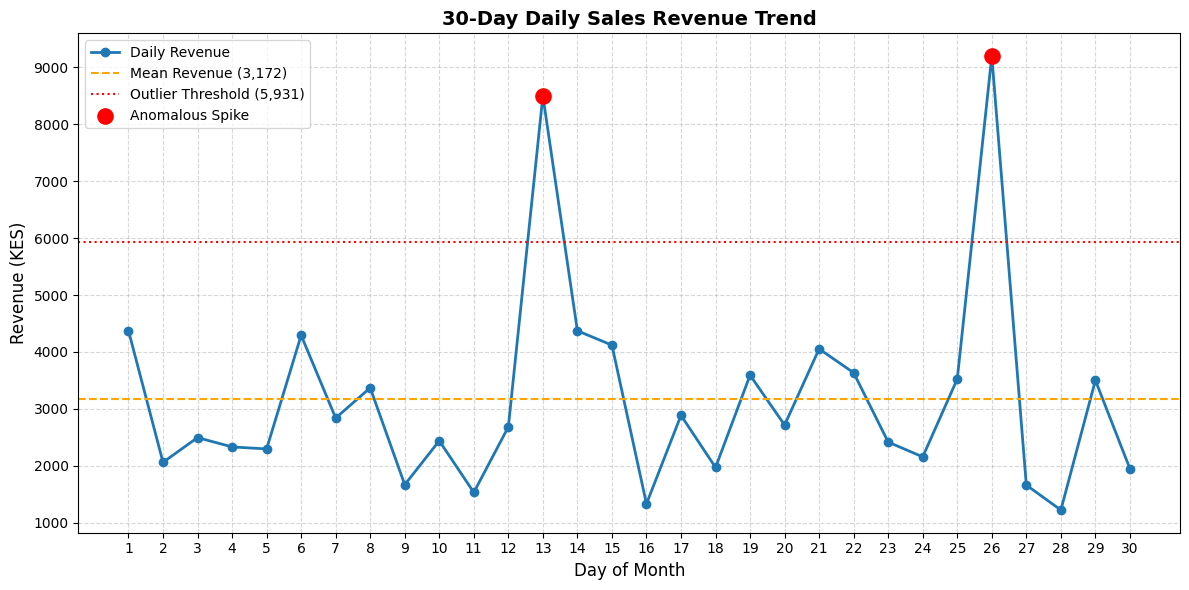

In [12]:
plt.figure(figsize=(12, 6))

# Plot daily sales line
plt.plot(df_sales['Day'], df_sales['Revenue'], marker='o', color='#1f77b4', linewidth=2, label='Daily Revenue')

# Highlight Average line
plt.axhline(mean_revenue, color='orange', linestyle='--', label=f'Mean Revenue ({mean_revenue:,.0f})')

# Highlight Upper Outlier Threshold
plt.axhline(upper_bound, color='red', linestyle=':', label=f'Outlier Threshold ({upper_bound:,.0f})')

# Plot Outliers in Red
plt.scatter(outliers['Day'], outliers['Revenue'], color='red', s=120, zorder=5, label='Anomalous Spike')

# Chart formatting
plt.title('30-Day Daily Sales Revenue Trend', fontsize=14, fontweight='bold')
plt.xlabel('Day of Month', fontsize=12)
plt.ylabel('Revenue (KES)', fontsize=12)
plt.xticks(df_sales['Day'])
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()

plt.show()